# `test_1` — numba vs JAX backend comparison

Runs the `test_test1` integration config (2D, **background ions**, weak beam `current = 0.05`, `particles_in_layer = 5000`, grid 1601 &times; 1000, **1 time step**) through both backends via the new `config['backend']` switch. The **same pre-generated initial beam** is injected into both backends.

The notebook compares the final plasma state (radial profiles and phase space), the on-axis / off-axis fields as functions of &xi;, and separates the *solver* contribution (feed numba's own beam density into the JAX march) from the rest of the pipeline.

In [1]:
import io
import contextlib
import warnings

import numpy as np
import matplotlib.pyplot as plt
import lcode
from lcode.config.config import Config
from lcode.alt_beam_generator.beam_generator import generate_beam

In [2]:
# Grid parameters (test_1 config)
transverse_step = 0.01     # dr
window_width    = 16.0
xi_step         = 0.01     # d(xi)
window_length   = 10.0

n_cells = int(window_width / transverse_step) + 1
n_xi    = int(window_length / xi_step)

config = {
    'geometry': '2d',
    'processing-unit-type': 'cpu',
    'transverse-step': transverse_step,
    'window-width': window_width,
    'xi-step': xi_step,
    'window-length': window_length,
    'time-limit': 1,
    'time-step': 1,
    'plasma-particles-per-cell': 10,
    'noise-reductor-enabled': False,
    'ion-model': 'background',
    # keep the per-xi wake fields (JAX): needed for the fields-vs-xi plots below. This makes the
    # JAX backend use its sequential driver (not the on-device wavefront) so history is retained.
    'save-field-history': True,
}

beam_params = {
    'current': 0.05,
    'particles_in_layer': 5000,
    'default': {'length': 5.013256548},
}

In [3]:
# Generate the initial beam ONCE and feed the identical particles to both backends.
initial_beam = generate_beam(Config(config), beam_params)
print(f'initial beam: {initial_beam.size} particles')

xi_field_names = ['E_z', 'E_r', 'B_f']   # fields whose xi-history we keep


class FieldHistory:
    """Diagnostic that records the radial field profile at every xi-layer (numba runs).

    Uses lcode's diagnostics hook `after_step_dxi`, called once per xi-layer -- no monkeypatching.
    """
    def __init__(self, field_names):
        self.field_names = field_names
        self.history = {name: [] for name in field_names}

    def pull_config(self, config):
        pass

    def after_step_dxi(self, current_time, xi, particles, fields, currents, rho_beam):
        for name in self.field_names:
            self.history[name].append(np.array(getattr(fields, name)))

    def dump(self, *args, **kwargs):
        pass


def run_backend(backend):
    """Run test_1 with the given backend on the shared initial beam.

    Returns (electrons, fields, currents, field_history). `field_history` holds the wake fields at
    every xi-layer of THIS run -- via a diagnostic for numba, from the backend for jax -- so the
    xi-plots use the exact same run as the radial profiles (no re-marching). Both backends now
    march the same xi_i = 0 .. xi_steps (n_xi + 1 layers), so the histories align layer-for-layer.
    """
    cfg = dict(config)
    cfg['backend'] = backend
    recorder = FieldHistory(xi_field_names) if backend == 'numba' else None

    sim = lcode.Simulation(config=cfg, diagnostics=[recorder] if recorder else [],
                           beam_parameters=beam_params, runas_filename='')
    sim._Simulation__beam_particles = initial_beam   # inject the shared beam
    with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sim.step()

    if recorder is not None:
        field_history = {name: np.array(vals) for name, vals in recorder.history.items()}
    else:
        field_history = sim._Simulation__push_solver._field_history

    plasma, fields, currents = sim._Simulation__push_solver._plasmastate
    return plasma['electrons'], fields, currents, field_history


electrons_numba, fields_numba, currents_numba, history_numba = run_backend('numba')
electrons_jax,   fields_jax,   currents_jax,   history_jax   = run_backend('jax')

r_axis = np.arange(n_cells) * transverse_step
print('done: numba & jax plasma states + xi field histories computed')
print(f'xi-layers: numba {history_numba["E_z"].shape[0]}, '
      f'jax {np.asarray(history_jax["E_z"]).shape[0]}')

initial beam: 1253052 particles


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done: numba & jax plasma states + xi field histories computed
xi-layers: numba 1001, jax 1001


## Field radial profiles (final &xi;-layer): numba vs JAX, and the difference

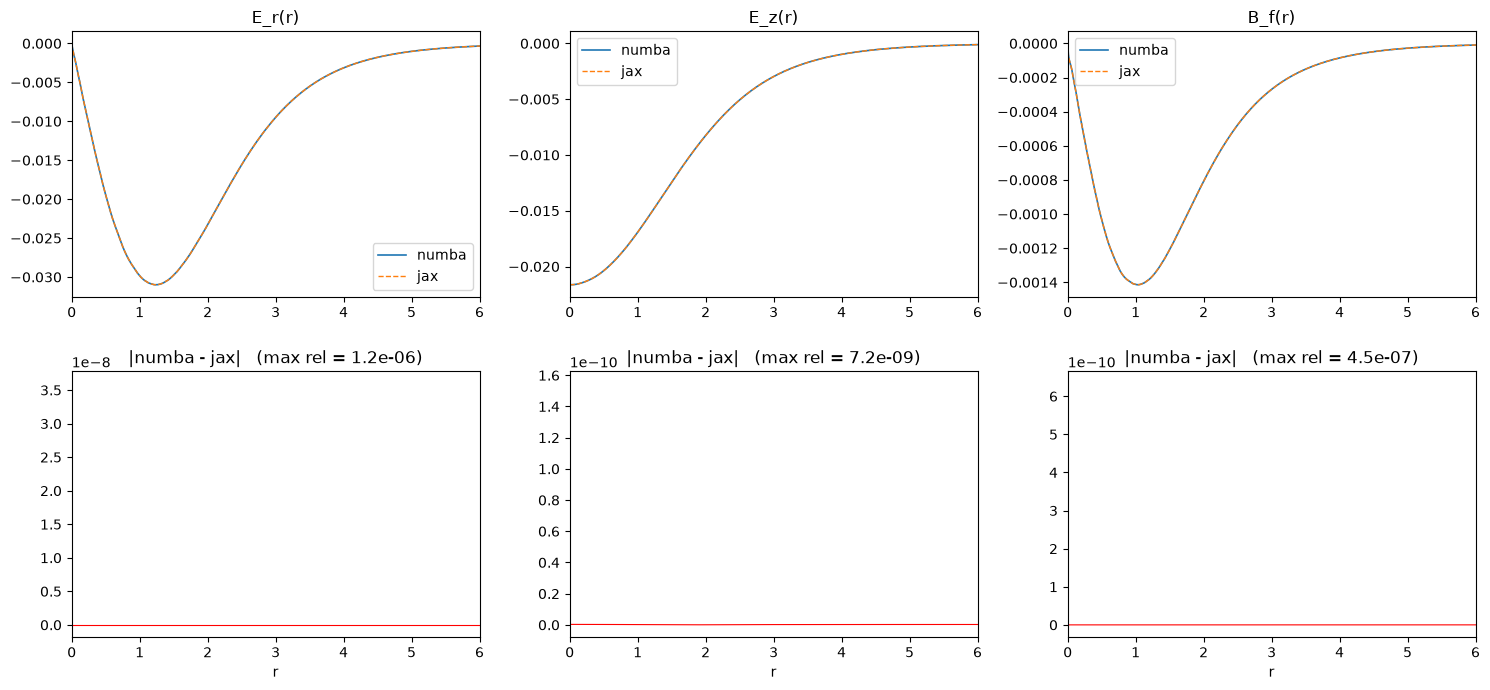

In [4]:
field_names = ['E_r', 'E_z', 'B_f']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for column, name in enumerate(field_names):
    numba_profile  = np.asarray(getattr(fields_numba, name))
    jax_profile    = np.asarray(getattr(fields_jax, name))
    difference     = np.abs(numba_profile - jax_profile)
    relative_error = difference.max() / np.abs(numba_profile).max()

    top = axes[0, column]
    top.plot(r_axis, numba_profile, label='numba', lw=1.2)
    top.plot(r_axis, jax_profile, '--', label='jax', lw=1.0)
    top.set_title(f'{name}(r)')
    top.set_xlim(0, 6)
    top.legend()

    bottom = axes[1, column]
    bottom.plot(r_axis, difference, color='red', lw=0.8)
    bottom.set_title(f'|numba - jax|   (max rel = {relative_error:.1e})')
    bottom.set_xlim(0, 6)
    bottom.set_xlabel('r')

fig.tight_layout()
plt.show()

## Current radial profiles (rho, j_r, j_z)

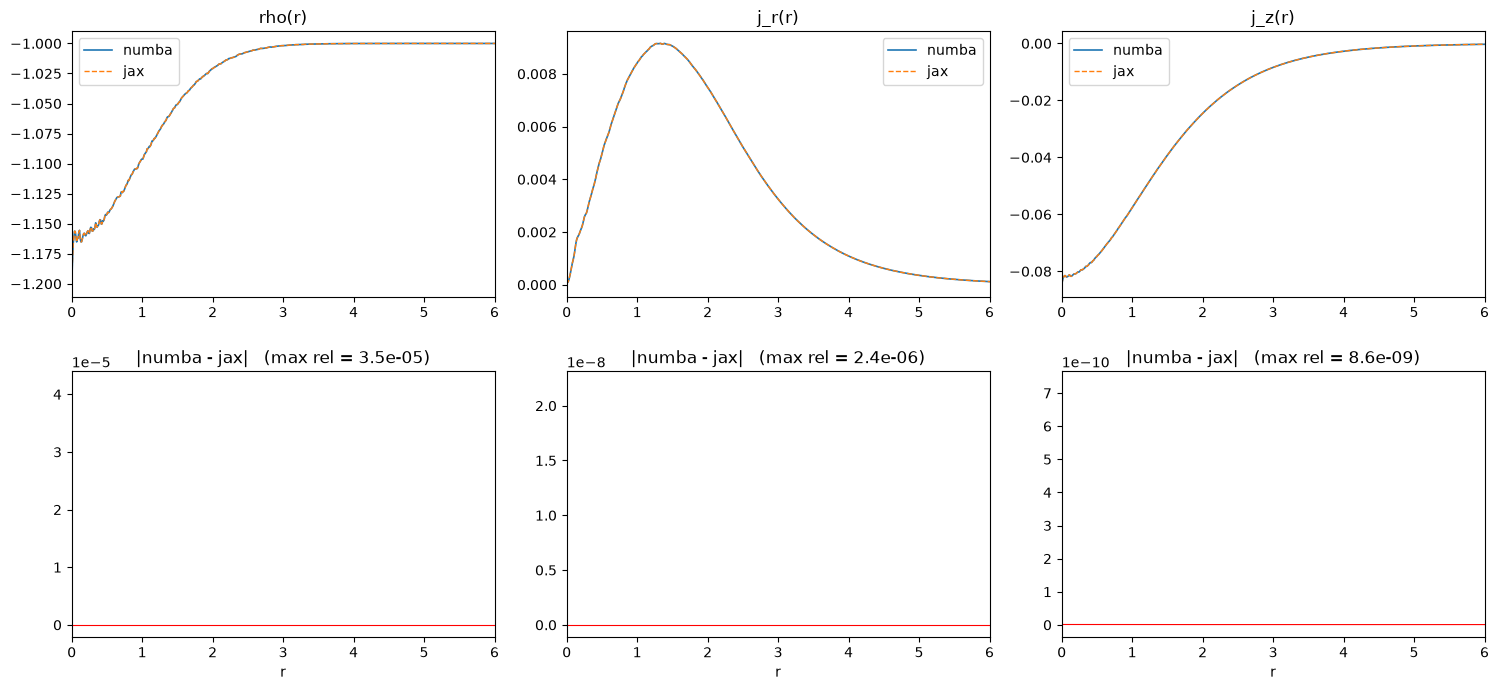

In [5]:
current_names = ['rho', 'j_r', 'j_z']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for column, name in enumerate(current_names):
    numba_profile  = np.asarray(getattr(currents_numba, name)[0])
    jax_profile    = np.asarray(getattr(currents_jax, name)[0])
    difference     = np.abs(numba_profile - jax_profile)
    relative_error = difference.max() / np.abs(numba_profile).max()

    top = axes[0, column]
    top.plot(r_axis, numba_profile, label='numba', lw=1.2)
    top.plot(r_axis, jax_profile, '--', label='jax', lw=1.0)
    top.set_title(f'{name}(r)')
    top.set_xlim(0, 6)
    top.legend()

    bottom = axes[1, column]
    bottom.plot(r_axis, difference, color='red', lw=0.8)
    bottom.set_title(f'|numba - jax|   (max rel = {relative_error:.1e})')
    bottom.set_xlim(0, 6)
    bottom.set_xlabel('r')

fig.tight_layout()
plt.show()

## Plasma electrons — transverse phase space (p_r vs r) and per-particle discrepancy

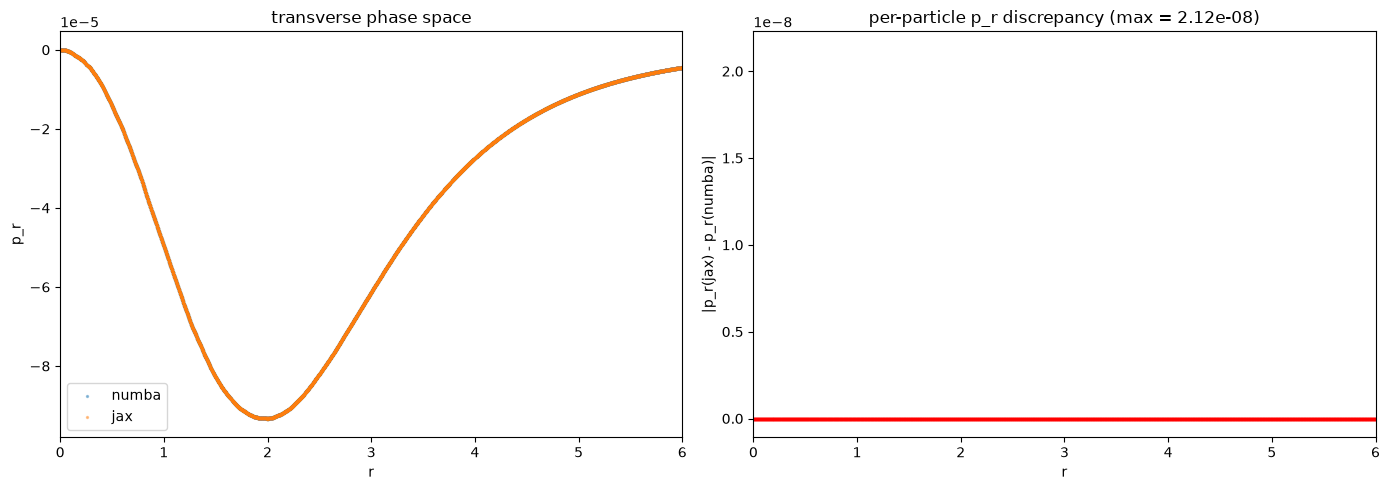

In [6]:
r_numba  = np.asarray(electrons_numba.r)
pr_numba = np.asarray(electrons_numba.p_r)
r_jax    = np.asarray(electrons_jax.r)
pr_jax   = np.asarray(electrons_jax.p_r)

# both backends keep the same particle ordering, so this is a per-particle difference
pr_difference = np.abs(pr_jax - pr_numba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(r_numba, pr_numba, s=2, alpha=0.4, label='numba')
axes[0].scatter(r_jax, pr_jax, s=2, alpha=0.4, label='jax')
axes[0].set_xlim(0, 6)
axes[0].set_xlabel('r')
axes[0].set_ylabel('p_r')
axes[0].set_title('transverse phase space')
axes[0].legend()

axes[1].scatter(r_numba, pr_difference, s=2, alpha=0.4, color='red')
axes[1].set_xlim(0, 6)
axes[1].set_xlabel('r')
axes[1].set_ylabel('|p_r(jax) - p_r(numba)|')
axes[1].set_title(f'per-particle p_r discrepancy (max = {pr_difference.max():.2e})')

fig.tight_layout()
plt.show()

## Fields on axis / off axis as functions of &xi;

Taken **directly from the two backend runs above** (numba recorded live, JAX from its own
`field_history`) &mdash; no re-marching. On axis (r = 0) only `E_z` is non-zero; `E_r` and `B_f`
are shown at r = 0.8. At the last &xi;-layer (&xi; = -10) these equal the on-axis values of the
radial-profile plots, since it is the same run.

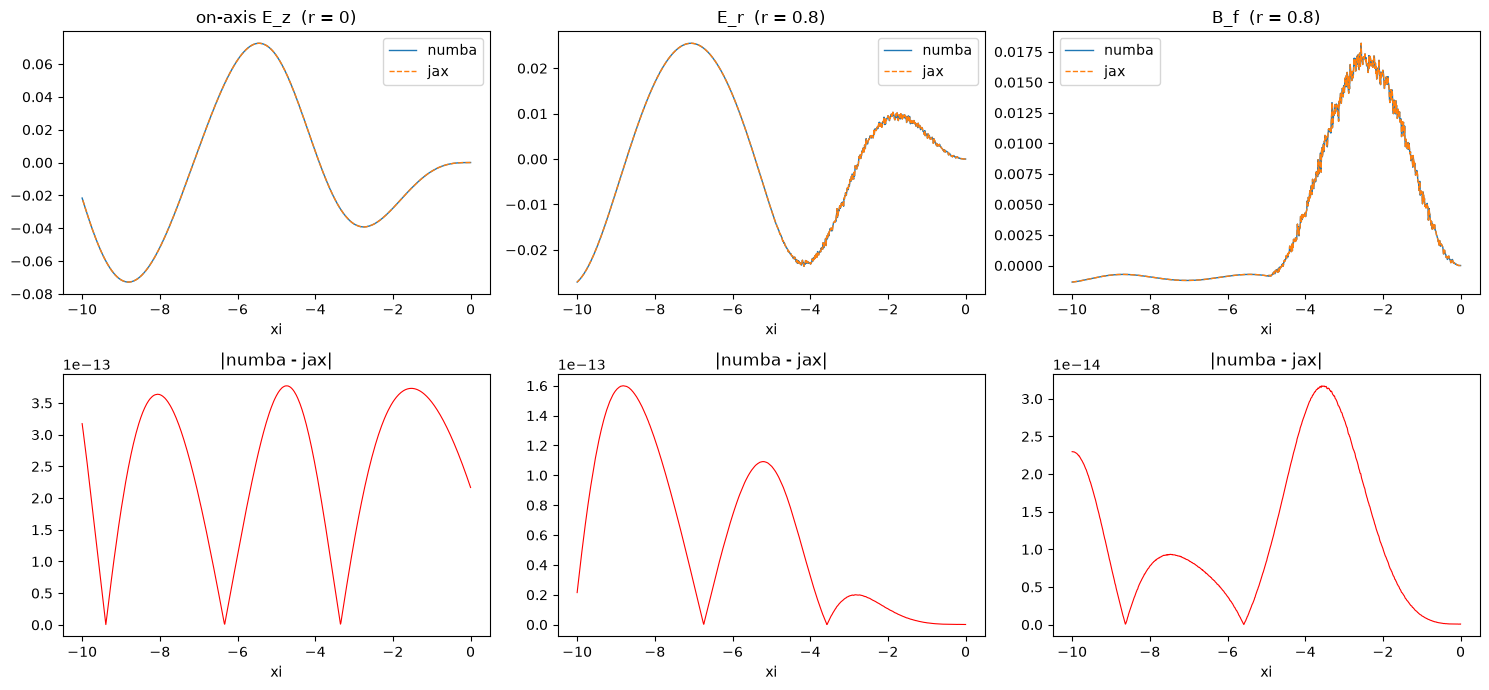

In [7]:
on_axis_cell  = 0
off_axis_cell = 80          # r = 0.8
n_layers = history_numba['E_z'].shape[0]     # n_xi + 1 (xi_i = 0 .. xi_steps)
xi_axis = -np.arange(n_layers) * xi_step     # xi = 0 .. -window_length

panels = [
    ('on-axis E_z  (r = 0)', 'E_z', on_axis_cell),
    ('E_r  (r = 0.8)',       'E_r', off_axis_cell),
    ('B_f  (r = 0.8)',       'B_f', off_axis_cell),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for column, (title, name, cell) in enumerate(panels):
    numba_curve = history_numba[name][:, cell]
    jax_curve   = history_jax[name][:, cell]

    top = axes[0, column]
    top.plot(xi_axis, numba_curve, label='numba', lw=1.0)
    top.plot(xi_axis, jax_curve, '--', label='jax', lw=1.0)
    top.set_title(title)
    top.set_xlabel('xi')
    top.legend()

    bottom = axes[1, column]
    bottom.plot(xi_axis, np.abs(numba_curve - jax_curve), color='red', lw=0.8)
    bottom.set_title('|numba - jax|')
    bottom.set_xlabel('xi')

fig.tight_layout()
plt.show()